# Eyebrow Analysis Pipeline

This notebook uses the MediaPipe Tasks API to extract facial landmarks and determine if a person's eyebrows are more masculine or feminine based on geometric heuristics.

In [29]:
#!pip install mediapipe opencv-python matplotlib numpy requests ipywidgets Pillow

In [30]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageOps

mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

## 1. Upload an Image
Click the upload button below to select a front-facing image from your computer.

Loading image from: C:/Users/PratikJPatel/Downloads/front.png


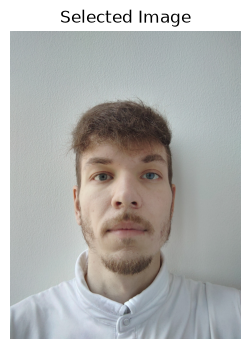

In [31]:
import tkinter as tk
from tkinter import filedialog
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
import io

# Open a native OS file dialog
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
file_path = filedialog.askopenfilename(
    title="Select a Face Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

if file_path:
    print(f"Loading image from: {file_path}")
    pil_image = Image.open(file_path)
    # Apply EXIF rotation to fix any sideways images from phones
    pil_image = ImageOps.exif_transpose(pil_image).convert('RGB')
    image_rgb = np.ascontiguousarray(np.array(pil_image))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image_rgb)
    plt.title('Selected Image')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No file selected!")
    image_rgb = None


## 2. Initialize Image & MediaPipe Model
**Note:** Run this cell *after* you have selected an image using the upload button.

In [32]:
if image_rgb is not None:
    # Download the model if it doesn't exist
    model_path = 'face_landmarker.task'
    if not os.path.exists(model_path):
        url = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
        response = requests.get(url)
        with open(model_path, 'wb') as f:
            f.write(response.content)

    # Initialize Face Landmarker
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(base_options=base_options,
                                           output_face_blendshapes=False,
                                           output_facial_transformation_matrixes=False,
                                           num_faces=1)
    detector = vision.FaceLandmarker.create_from_options(options)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if detection_result.face_landmarks:
        face_landmarks = detection_result.face_landmarks[0]
        print("✅ Face landmarks detected!")
    else:
        print("❌ No face detected in the image.")
        face_landmarks = None
else:
    face_landmarks = None

✅ Face landmarks detected!


## 3. Eyebrow Geometric Heuristics

C:\Users\PratikJPatel\AppData\Local\Temp\ipykernel_16532\1040804968.py:43: RuntimeWarning: invalid value encountered in scalar divide
  cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


{
  "Vertical Height (mm)": 25.98,
  "Elevation Ratio": 1.0,
  "Apex Angle (deg)": NaN,
  "Position": "High Set",
  "Tilt": "Upturned",
  "Virility": "Moderate",
  "Shape": "Rounded"
}


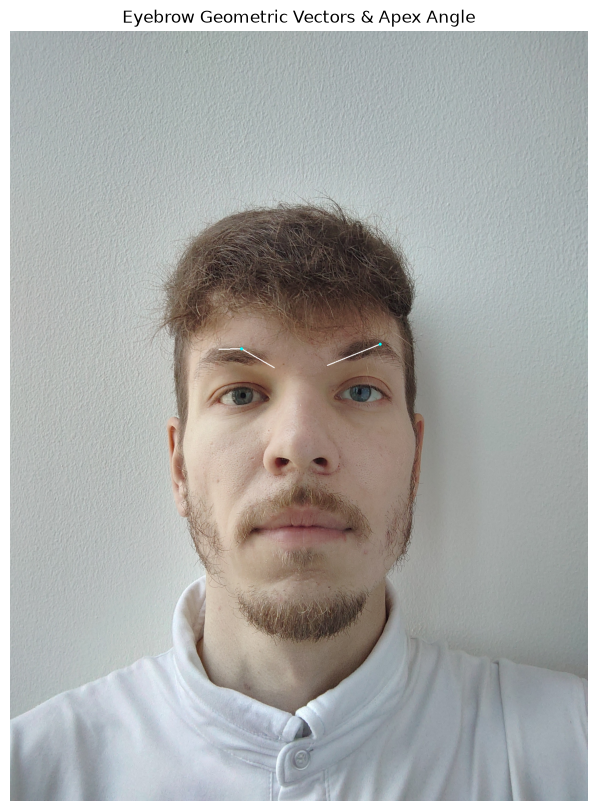

In [34]:
def analyze_eyebrows(landmarks, image_width, image_height):
    import numpy as np
    def pt(idx):
        return np.array([landmarks[idx].x * image_width, landmarks[idx].y * image_height])
        
    # Calculate IPD (Interpupillary Distance) to convert to mm
    p_lp = pt(468)
    p_rp = pt(473)
    ipd_px = np.linalg.norm(p_lp - p_rp)
    px_to_mm = 63.0 / ipd_px
    
    # Eyebrow points
    # Right Eyebrow (image left side)
    right_inner = pt(55)
    right_outer = pt(105)
    right_eb_upper = [156, 70, 63, 105, 66, 107, 55, 65]
    right_peak = min([pt(i) for i in right_eb_upper], key=lambda p: p[1])
    right_eye = p_rp
    
    # Left Eyebrow (image right side)
    left_inner = pt(285)
    left_outer = pt(334)
    left_eb_upper = [383, 300, 293, 334, 296, 336, 285, 295]
    left_peak = min([pt(i) for i in left_eb_upper], key=lambda p: p[1])
    left_eye = p_lp
    
    # 1. Brow Peak Vertical Height (mm)
    right_height_px = right_eye[1] - right_peak[1]
    left_height_px = left_eye[1] - left_peak[1]
    avg_height_mm = ((right_height_px + left_height_px) / 2.0) * px_to_mm
    
    # 2. Brow Elevation Ratio
    right_eye_width = np.linalg.norm(pt(133) - pt(33))
    left_eye_width = np.linalg.norm(pt(362) - pt(263))
    avg_eye_width = (right_eye_width + left_eye_width) / 2.0
    avg_height_px = (right_height_px + left_height_px) / 2.0
    elevation_ratio = avg_height_px / avg_eye_width
    
    # 3. Brow Apex Angle (Degrees)
    def calc_angle(apex, p1, p2):
        v1 = p1 - apex
        v2 = p2 - apex
        cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(cosine_angle))
        
    right_angle = calc_angle(right_peak, right_inner, right_outer)
    left_angle = calc_angle(left_peak, left_inner, left_outer)
    avg_angle = (right_angle + left_angle) / 2.0
    
    # Classifications
    if avg_height_mm > 22.0:
        position = "High Set"
    elif avg_height_mm < 18.0:
        position = "Low Set"
    else:
        position = "Average Set"
        
    right_tilt = right_inner[1] - right_outer[1]
    left_tilt = left_inner[1] - left_outer[1]
    avg_tilt = (right_tilt + left_tilt) / 2.0
    if avg_tilt > 5:
        tilt = "Upturned"
    elif avg_tilt < -5:
        tilt = "Downturned"
    else:
        tilt = "Straight"
        
    if avg_angle < 135:
        shape = "Arched"
    elif avg_angle > 155:
        shape = "Straight"
    else:
        shape = "Rounded"
        
    virility = "Moderate" 
    
    return {
        "Vertical Height (mm)": round(avg_height_mm, 2),
        "Elevation Ratio": round(elevation_ratio, 2),
        "Apex Angle (deg)": round(avg_angle, 2),
        "Position": position,
        "Tilt": tilt,
        "Virility": virility,
        "Shape": shape,
        "Vectors": {
            "Right": [right_inner, right_peak, right_outer],
            "Left": [left_inner, left_peak, left_outer]
        }
    }

if face_landmarks:
    h, w, _ = image_rgb.shape
    results = analyze_eyebrows(face_landmarks, w, h)
    import json
    print(json.dumps({k:v for k,v in results.items() if k != "Vectors"}, indent=2))

    # Visualization
    annotated_image = image_rgb.copy()
    import cv2
    
    # Draw vectors
    vecs = results["Vectors"]
    for side in ["Right", "Left"]:
        inner, peak, outer = vecs[side]
        cv2.line(annotated_image, (int(inner[0]), int(inner[1])), (int(peak[0]), int(peak[1])), (255, 255, 255), 2)
        cv2.line(annotated_image, (int(peak[0]), int(peak[1])), (int(outer[0]), int(outer[1])), (255, 255, 255), 2)
        cv2.circle(annotated_image, (int(peak[0]), int(peak[1])), 4, (0, 255, 255), -1)
        
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image)
    plt.title("Eyebrow Geometric Vectors & Apex Angle")
    plt.axis('off')
    plt.show()


## 4. Scoring logic

## 5. UI Visualization (Matched to Reference)